In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import matplotlib.cm as cm

params = {
   'axes.labelsize': 20,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 20,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [ ]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']

# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [21]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

In [27]:
def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []
    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            crossed = False
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    crossed = True
                    break
            if not crossed:
                endpoints.append(-1) # Critical fix to maintain 1:1 mapping with galaxies
        endpoints_gals.append(np.array(endpoints))
    return endpoints_gals

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


def compute_ratios(gals_list, endpoints, element='Fe'):
    """Calculates arrays and the max plot value for a specific element ratio."""
    all_ratios, scatter_maxes = [], []
    for k, gal in enumerate(gals_list):
        if element == 'Fe':
            ratio = gal.compute_z_Fe_Ia() / gal.compute_z_Fe_CC()
        elif element == 'X':
            ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()
        
        all_ratios.append(ratio)
        for i in range(len(endpoints)):
            if endpoints[i][k] != -1:
                scatter_maxes.append(ratio[endpoints[i][k]])
                
    return all_ratios, (max(scatter_maxes) if scatter_maxes else 1)

import matplotlib.lines as mlines

def plot_5_panel_abundances(
    data, gals_list, endpoints, slopes, intercepts,
    x_col='FE_MG', y_col='MN_MG',
    gal_x_attr='Fe_Mg', gal_y_attr='Mn_Mg',
    ylabel='[Mn/Mg]', ylim=(-1.8, 0.40),
    color_by='tau',           # Options: 'tau', 'eta', 'ratio', or 'sfr'
    ratio_data=None,          # Required if color_by='ratio' -> (all_ratios, vmax)
    ratio_label=r'$Ratio$',   # Required if color_by='ratio'
    sfr_map=None              # Required if color_by='sfr' -> dict of labels to colors
):
    fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharex=True, sharey=True)
    axes = axes.flatten()

    # --- Setup colormap and normalizer ---
    is_continuous = True
    cmap = plt.get_cmap('inferno')

    if color_by == 'tau':
        vals = [gal.tau_star_arr[0] for gal in gals_list]
        norm = mcolors.Normalize(vmin=min(vals), vmax=max(vals))
        cbar_label = r'$\tau_*$'
    elif color_by == 'eta':
        vals = [gal.eta_arr[0] for gal in gals_list]
        norm = mcolors.LogNorm(vmin=min(vals), vmax=max(vals)) # Kept your LogNorm!
        cbar_label = r'$\eta$'
    elif color_by == 'ratio':
        all_ratios, vmax = ratio_data
        norm = mcolors.Normalize(vmin=0, vmax=vmax)
        cbar_label = ratio_label
    elif color_by == 'sfr':
        is_continuous = False
    else:
        raise ValueError("color_by must be 'tau', 'eta', 'ratio', or 'sfr'")

    for i, ax in enumerate(axes):
        # Background & Lines
        subset = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(subset[x_col], subset[y_col], s=0.1, color='gray', alpha=0.3)

        y_centers = slopes[i] * fe_mg_bin_centers + intercepts[i]
        y_lower = slopes[i] * np.linspace(-0.6, 0.25, 100) + intercepts[i] - 0.15
        y_upper = slopes[i] * np.linspace(-0.6, 0.25, 100) + intercepts[i] + 0.15
        
        ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)
        ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
        ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

        # Colored Scatter Endpoints
        for k, (gal, idx) in enumerate(zip(gals_list, endpoints[i])):
            if idx != -1: 
                gal_x = getattr(gal, gal_x_attr)[idx]
                gal_y = getattr(gal, gal_y_attr)[idx]
                
                # Determine specific color for this point
                if color_by == 'tau':
                    current_color = cmap(norm(gal.tau_star_arr[0]))
                elif color_by == 'eta':
                    current_color = cmap(norm(gal.eta_arr[0]))
                elif color_by == 'ratio':
                    current_color = cmap(norm(all_ratios[k][idx]))
                elif color_by == 'sfr':
                    sfr = gal.m_g_array
                    if np.array_equal(sfr, m_g_array_const): sfr_label = "const SFR"
                    elif np.array_equal(sfr, m_g_array_exp): sfr_label = "exp SFR"
                    elif np.array_equal(sfr, m_g_array_rise_fall_1): sfr_label = "rise+fall  1"
                    elif np.array_equal(sfr, m_g_array_rise_fall_2): sfr_label = "rise+fall  2"
                    elif np.array_equal(sfr, m_g_array_rise_fall_3): sfr_label = "rise+fall  3"
                    else: sfr_label = "unknown SFR"
                    current_color = sfr_map.get(sfr_label, 'black')

                ax.plot(gal_x, gal_y, marker='o', color=current_color, linewidth=0,
                        markeredgecolor='black', markersize=8, zorder=11)

        # Formatting
        if i == 0: ax.set_ylabel(ylabel)
        ax.set_title(rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$', fontsize=14)
        ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(ylim)

    fig.supxlabel('[Fe/Mg]')
    
    # --- Colorbar or Legend ---
    if is_continuous:
        fig.subplots_adjust(wspace=0)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([]) 
        cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
        cbar.set_label(cbar_label, fontsize=20)
    else:
        fig.subplots_adjust(wspace=0, right=0.9)
        legend_elements = [mlines.Line2D([0], [0], color=color, lw=0, marker='o', 
                                         markeredgecolor='black', markersize=8, label=label) 
                           for label, color in sfr_map.items()]
        fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.99, 0.5), 
                   fontsize=14, title="SFR Type", title_fontsize=16)

    plt.show()

In [28]:
from scipy.stats import linregress

n_bins = 5

slopes_mn_fe, intercepts_mn_fe = np.zeros(n_bins), np.zeros(n_bins)
slopes_mn_mg, intercepts_mn_mg = np.zeros(n_bins), np.zeros(n_bins)

for i in range(n_bins):
    subset = data[data['MG_H_big_bin'] == i]
    x = subset['FE_MG']
    
    # Loop through both y-variables to save space
    for y_col, slopes, intercepts in [
        ('MN_FE', slopes_mn_fe, intercepts_mn_fe), 
        ('MN_MG', slopes_mn_mg, intercepts_mn_mg)
    ]:
        y = subset[y_col]
        mask = np.isfinite(x) & np.isfinite(y)
        
        if mask.sum() > 2:
            slope, intercept, *_ = linregress(x[mask], y[mask])
            slopes[i] = slope
            intercepts[i] = intercept

In [29]:
gcc_Mn_def = 0.40
gcc_ratio_def = 2
alpha_cc_def = 0.60
alpha_ia_def = 0.30

In [30]:
# SFRs

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]
#sfrs = [m_g_array_rise_fall_1]

In [39]:
etas = np.logspace(-2, 1, 10)
tau_stars = np.linspace(0.5, 6, 10)

#etas = [0]
#tau_stars = [2]

gals_list_all = []

n_gals = len(etas) * len(tau_stars) * len(sfrs)
print("n_gals = ", n_gals)

n_gals =  500


In [40]:
for i_eta in range(len(etas)):
    for i_taustar in range(len(tau_stars)):
        for i_sfrs in range(len(sfrs)):
            eta = etas[i_eta]
            tau_star = tau_stars[i_taustar]
            sfr = sfrs[i_sfrs]

            gals_list_all.append(evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_def, g_ratio_Mn=gcc_ratio_def,
                                     alpha_cc_Mn=alpha_cc_def, alpha_Ia_Mn=alpha_ia_def))
            
len(gals_list_all)

500

In [61]:
random.seed(42)
random_gals_list = random.sample(gals_list_all, 100)

In [62]:
endpoints = find_endpoints(random_gals_list, mg_h_big_bin_centers)

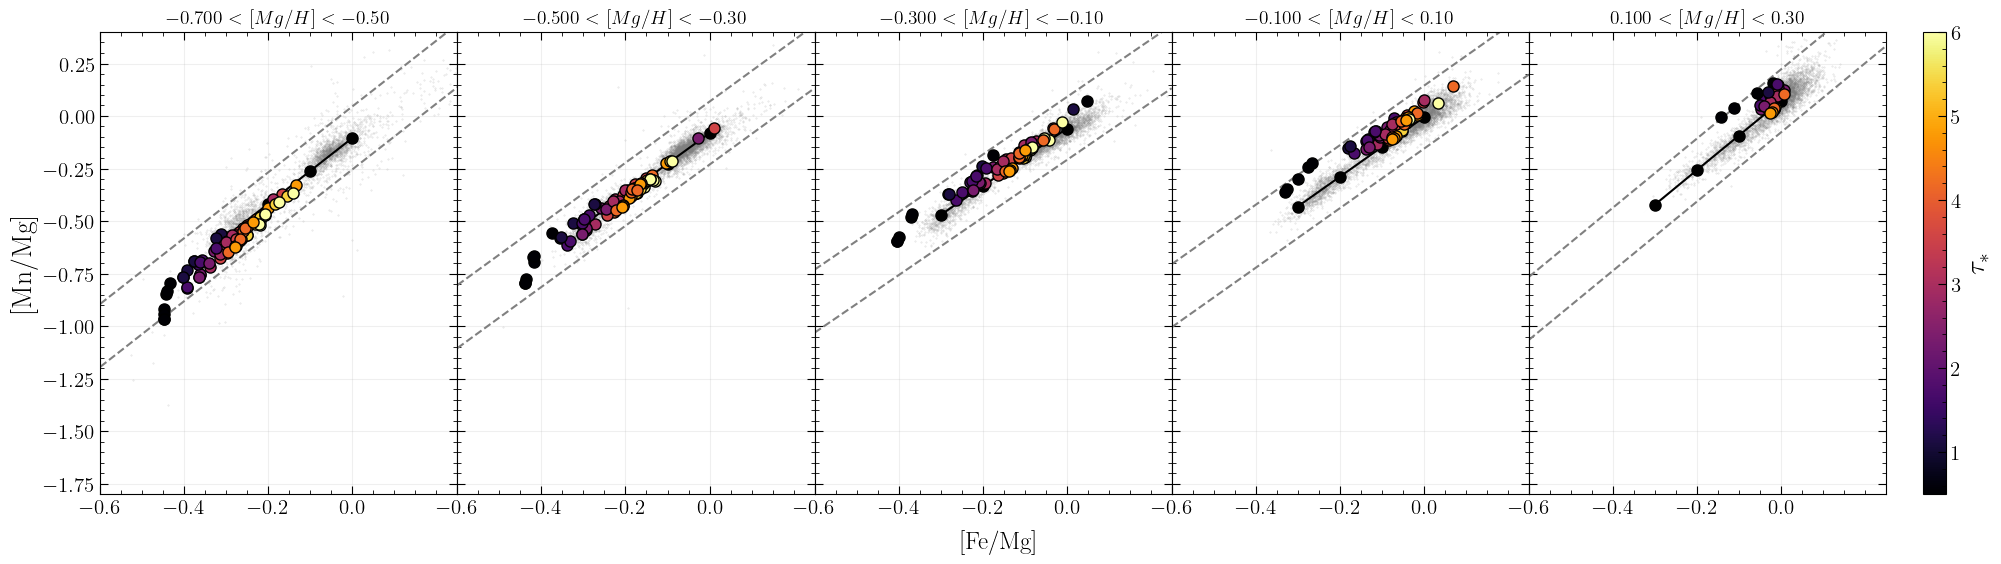

In [63]:
plot_5_panel_abundances(
    data=data, gals_list=random_gals_list, endpoints=endpoints,
    slopes=slopes_mn_mg, intercepts=intercepts_mn_mg,
    color_by='tau'
)

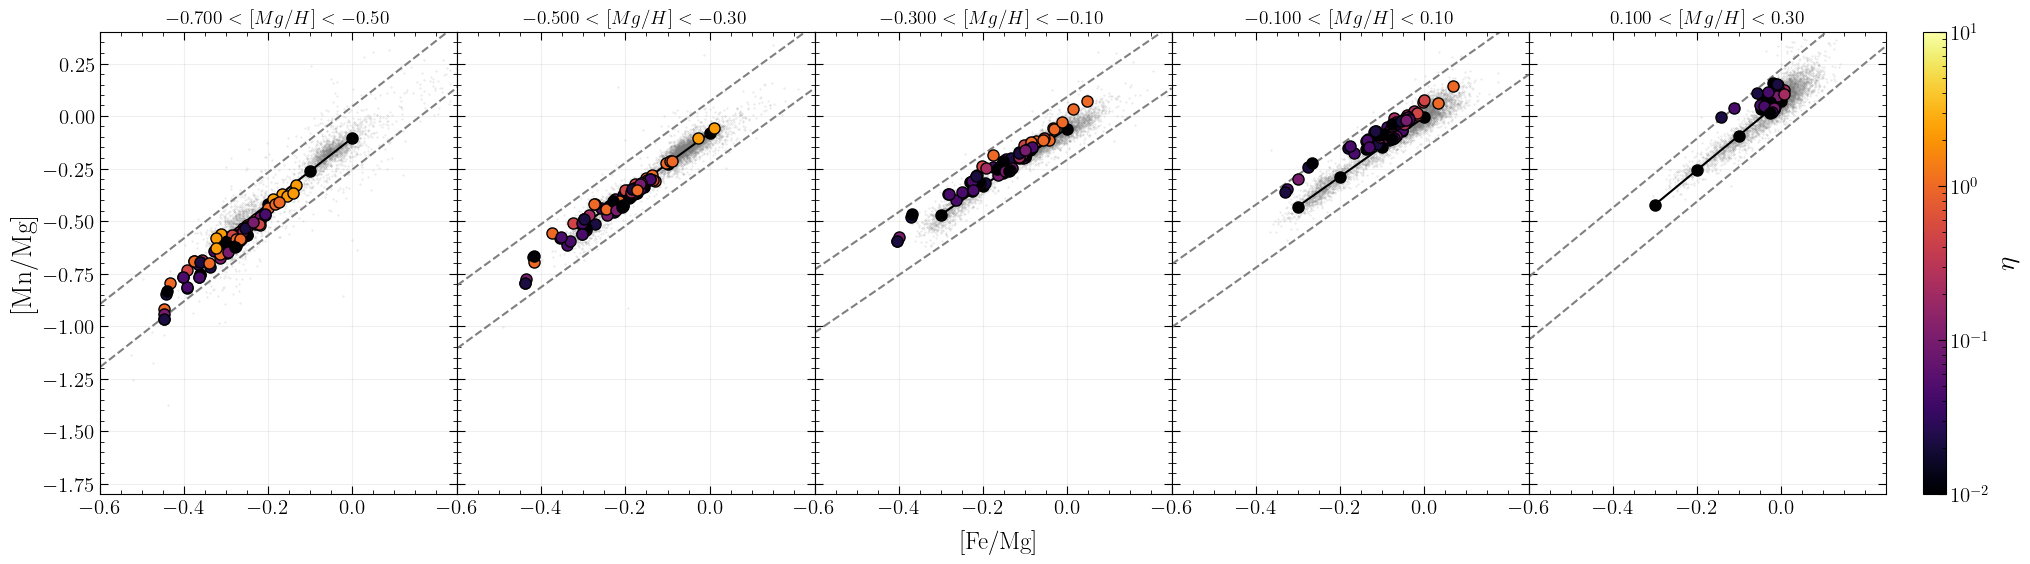

In [64]:
# 1. Get endpoints
endpoints = find_endpoints(random_gals_list, mg_h_big_bin_centers)

# 2. Plot directly
plot_5_panel_abundances(
    data=data, gals_list=random_gals_list, endpoints=endpoints,
    slopes=slopes_mn_mg, intercepts=intercepts_mn_mg,
    color_by='eta' # or 'tau', or 'sfr'
)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24826/1837134276.py:34: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_Fe_Ia() / gal.compute_z_Fe_CC()


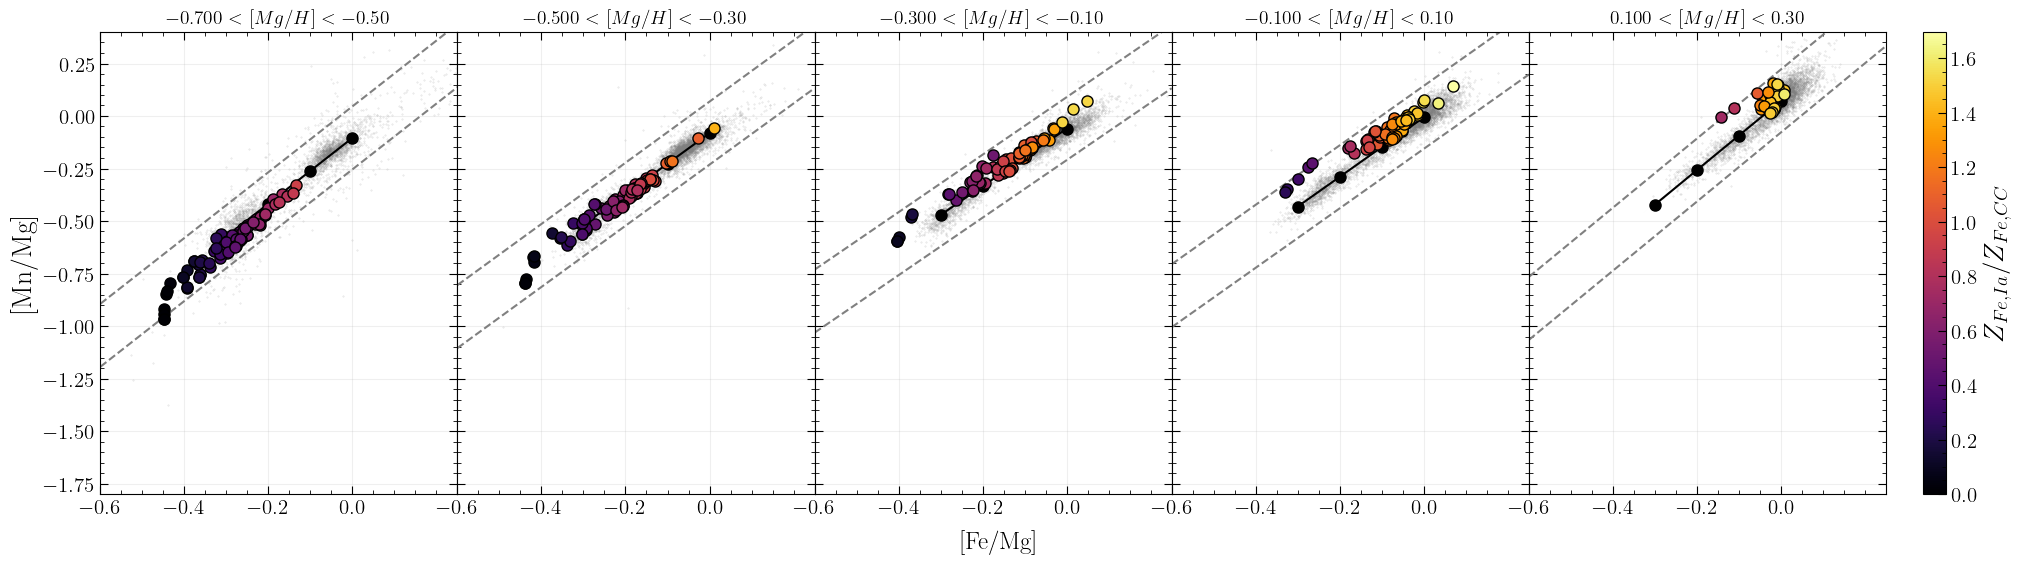

In [71]:
# 1. First, calculate the ratios (Let's say for Fe)
ratio_data = compute_ratios(random_gals_list, endpoints, element='Fe')

# 2. Then, plot and pass that data in!
plot_5_panel_abundances(
    data=data, 
    gals_list=random_gals_list, 
    endpoints=endpoints,
    slopes=slopes_mn_mg, 
    intercepts=intercepts_mn_mg,
    color_by='ratio',            # You set this correctly...
    ratio_data=ratio_data,       # ...but you just needed to add this line!
    ratio_label=r'$Z_{Fe, Ia} / Z_{Fe, CC}$'
)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24826/1837134276.py:36: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()


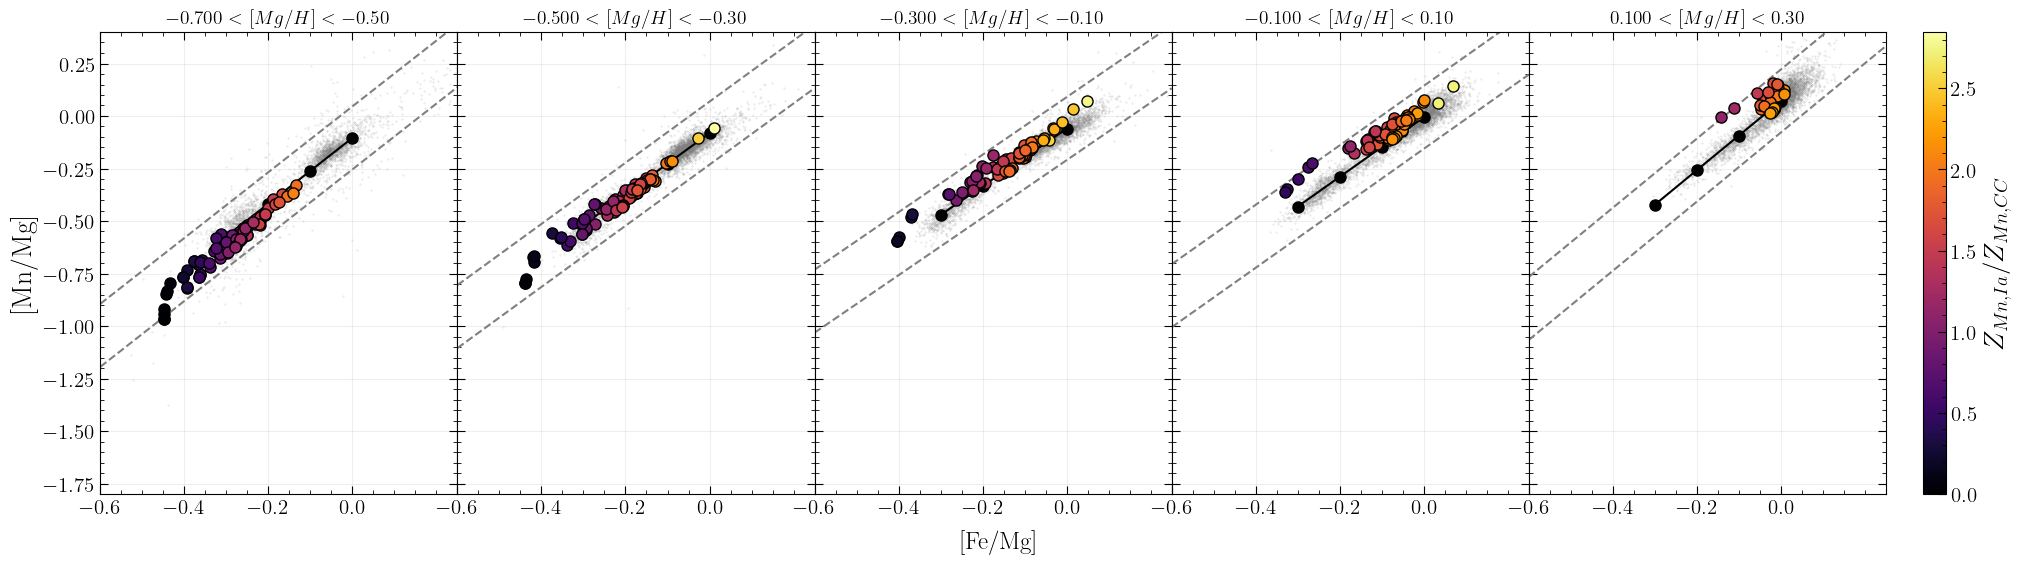

In [73]:
# 1. First, calculate the ratios (Let's say for Fe)
ratio_data = compute_ratios(random_gals_list, endpoints, element='X')

# 2. Then, plot and pass that data in!
plot_5_panel_abundances(
    data=data, 
    gals_list=random_gals_list, 
    endpoints=endpoints,
    slopes=slopes_mn_mg, 
    intercepts=intercepts_mn_mg,
    color_by='ratio',            # You set this correctly...
    ratio_data=ratio_data,       # ...but you just needed to add this line!
    ratio_label=r'$Z_{Mn, Ia} / Z_{Mn, CC}$'
)

In [67]:
# Define this map once globally
sfr_color_map = {
    "const SFR": "tab:blue",
    "exp SFR": "tab:orange",
    "rise+fall  1": "tab:green",
    "rise+fall  2": "tab:red",
    "rise+fall  3": "tab:purple",
    "unknown SFR": "tab:gray"
}

def plot_5_panel_sfr(
    data, gals_list, endpoints, slopes, intercepts,
    x_col='FE_MG', y_col='MN_FE',
    gal_x_attr='Fe_Mg', gal_y_attr='Mn_Fe',
    ylabel='[Mn/Fe]', ylim=(-1.2, 0.40)
):
    """Generates the 5-panel abundance plot colored by discrete SFR types."""
    fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        # Background data
        subset = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(subset[x_col], subset[y_col], s=0.1, color='gray', alpha=0.3)

        # Median and parallel lines
        y_centers = slopes[i] * fe_mg_bin_centers + intercepts[i]
        y_lower = slopes[i] * np.linspace(-0.6, 0.25, 100) + intercepts[i] - 0.15
        y_upper = slopes[i] * np.linspace(-0.6, 0.25, 100) + intercepts[i] + 0.15
        
        ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)
        ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
        ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

        for k, (gal, idx) in enumerate(zip(gals_list, endpoints[i])):
            if idx != -1: 
                gal_x = getattr(gal, gal_x_attr)[idx]
                gal_y = getattr(gal, gal_y_attr)[idx]
                
                sfr = gal.m_g_array
                if np.array_equal(sfr, m_g_array_const): sfr_label = "const SFR"
                elif np.array_equal(sfr, m_g_array_exp): sfr_label = "exp SFR"
                elif np.array_equal(sfr, m_g_array_rise_fall_1): sfr_label = "rise+fall  1"
                elif np.array_equal(sfr, m_g_array_rise_fall_2): sfr_label = "rise+fall  2"
                elif np.array_equal(sfr, m_g_array_rise_fall_3): sfr_label = "rise+fall  3"
                else: sfr_label = "unknown SFR"

                current_color = sfr_color_map.get(sfr_label, 'tab:gray')

                ax.plot(gal_x, gal_y, marker='o', color=current_color, linewidth=0,
                        markeredgecolor='black', markersize=8, zorder=11)

        if i == 0: ax.set_ylabel(ylabel)
        ax.set_title(rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$', fontsize=14)
        ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(ylim)

    fig.supxlabel('[Fe/Mg]')
    fig.subplots_adjust(wspace=0, right=0.9)

    # Custom Legend
    legend_elements = [mlines.Line2D([0], [0], color=color, lw=0, marker='o', 
                                     markeredgecolor='black', markersize=8, label=label) 
                       for label, color in sfr_color_map.items()]

    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.99, 0.5), 
               fontsize=14, title="SFR Type", title_fontsize=16)

    plt.show()

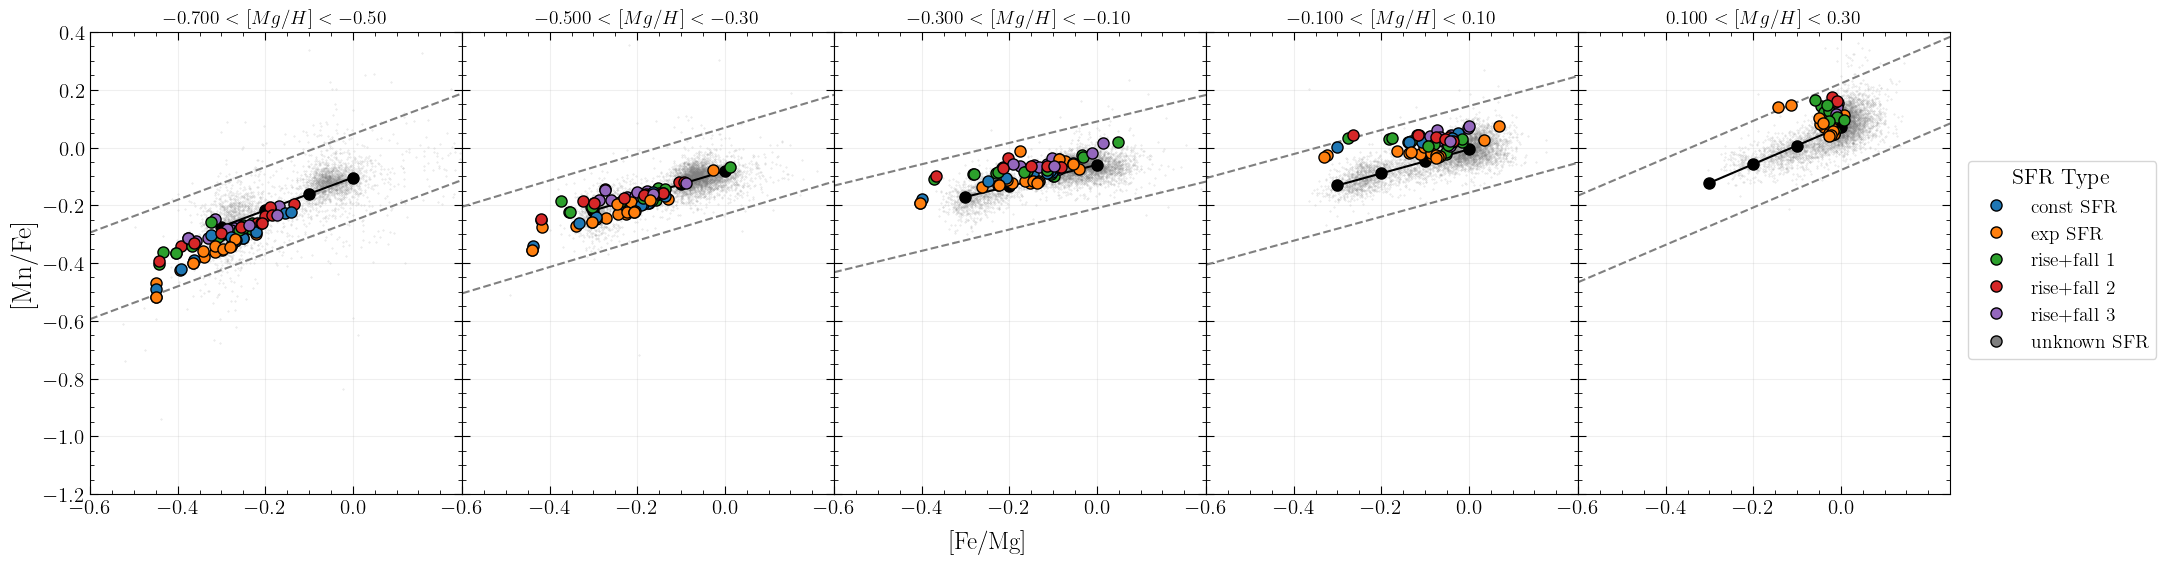

In [70]:
plot_5_panel_sfr(
    data=data, gals_list=random_gals_list, endpoints=endpoints,
    slopes=slopes_mn_fe, intercepts=intercepts_mn_fe
)

In [75]:
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_2_panel_evolution(
    data, gals_list, endpoints,
    color_by='ratio',           # Options: 'tau', 'eta', 'ratio', or 'sfr'
    ratio_data=None,            # Required if color_by='ratio' -> (all_ratios, vmax)
    ratio_label=r'$Ratio$',     # Required if color_by='ratio'
    sfr_map=None                # Required if color_by='sfr' -> dict of labels to colors
):
    """Generates the 2-panel [Fe/Mg] and [Mn/Mg] vs [Mg/H] evolution tracks."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Setup colormap and normalizer ---
    is_continuous = True
    cmap = plt.get_cmap('inferno')

    if color_by == 'tau':
        vals = [gal.tau_star_arr[0] for gal in gals_list]
        norm = mcolors.Normalize(vmin=min(vals), vmax=max(vals))
        cbar_label = r'$\tau_*$'
    elif color_by == 'eta':
        vals = [gal.eta_arr[0] for gal in gals_list]
        v_min, v_max = min(vals), max(vals)
        if v_min == v_max:
            if v_min == 0: v_min, v_max = 0, 1
            else: v_min, v_max = v_min * 0.9, v_max * 1.1
        norm = mcolors.LogNorm(vmin=v_min, vmax=v_max) if v_min > 0 else mcolors.Normalize(vmin=v_min, vmax=v_max)
        cbar_label = r'$\eta$'
    elif color_by == 'ratio':
        all_ratios, vmax = ratio_data
        norm = mcolors.Normalize(vmin=0, vmax=vmax)
        cbar_label = ratio_label
    elif color_by == 'sfr':
        is_continuous = False
    else:
        raise ValueError("color_by must be 'tau', 'eta', 'ratio', or 'sfr'")

    # --- Panel 1: [Fe/Mg] vs [Mg/H] ---
    axes[0].scatter(data['MG_H'], data['FE_MG'], s=0.01, color='gray', alpha=0.3)
    axes[0].set_xlim(-0.8, 0.5)
    axes[0].set_ylim(-0.5, 0.3)
    axes[0].set_xlabel('[Mg/H]')
    axes[0].set_ylabel('[Fe/Mg]')
    axes[0].grid(True, alpha=0.1)

    # --- Panel 2: [Mn/Mg] vs [Mg/H] ---
    axes[1].scatter(data['MG_H'], data['MN_MG'], s=0.01, color='gray', alpha=0.3)
    axes[1].set_xlim(-0.8, 0.5)
    axes[1].set_ylim(-1.25, 0.5)
    axes[1].set_xlabel('[Mg/H]')
    axes[1].set_ylabel('[Mn/Mg]')
    axes[1].grid(True, alpha=0.1)

    # --- Plot Galaxies ---
    for k, gal in enumerate(gals_list):
        # 1. Background evolution tracks
        axes[0].plot(gal.Mg_H, gal.Fe_Mg, color='gray', alpha=0.5, zorder=1)
        axes[1].plot(gal.Mg_H, gal.Mn_Mg, color='gray', alpha=0.5, zorder=1)
        
        # 2. Get valid endpoints for this galaxy across all bins
        valid_idxs = [endpoints[i][k] for i in range(len(endpoints)) if endpoints[i][k] != -1]
        
        if valid_idxs:
            # 3. Handle colors differently depending on continuous array vs single value
            if color_by == 'ratio':
                c_args = {'c': all_ratios[k][valid_idxs], 'cmap': cmap, 'norm': norm}
            else:
                if color_by == 'tau':
                    col = cmap(norm(gal.tau_star_arr[0]))
                elif color_by == 'eta':
                    col = cmap(norm(gal.eta_arr[0]))
                elif color_by == 'sfr':
                    sfr = gal.m_g_array
                    if np.array_equal(sfr, m_g_array_const): sfr_label = "const SFR"
                    elif np.array_equal(sfr, m_g_array_exp): sfr_label = "exp SFR"
                    elif np.array_equal(sfr, m_g_array_rise_fall_1): sfr_label = "rise+fall  1"
                    elif np.array_equal(sfr, m_g_array_rise_fall_2): sfr_label = "rise+fall  2"
                    elif np.array_equal(sfr, m_g_array_rise_fall_3): sfr_label = "rise+fall  3"
                    else: sfr_label = "unknown SFR"
                    col = sfr_map.get(sfr_label, 'black')
                
                c_args = {'color': col}

            # 4. Plot the scatter points
            axes[0].scatter(gal.Mg_H[valid_idxs], gal.Fe_Mg[valid_idxs], 
                            s=50, zorder=10, marker='o', edgecolors='black', **c_args)
            
            axes[1].scatter(gal.Mg_H[valid_idxs], gal.Mn_Mg[valid_idxs], 
                            s=50, zorder=10, marker='o', edgecolors='black', **c_args)

    plt.tight_layout()

    # --- Colorbar or Legend ---
    if is_continuous:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([]) 
        cbar = fig.colorbar(sm, ax=axes, fraction=0.05, pad=0.04)
        cbar.set_label(cbar_label, fontsize=16)
    else:
        legend_elements = [mlines.Line2D([0], [0], color=color, lw=0, marker='o', 
                                         markeredgecolor='black', markersize=8, label=label) 
                           for label, color in sfr_map.items()]
        fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.1, 0.5), 
                   fontsize=14, title="SFR Type", title_fontsize=16)

    plt.show()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_24826/1837134276.py:34: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_Fe_Ia() / gal.compute_z_Fe_CC()


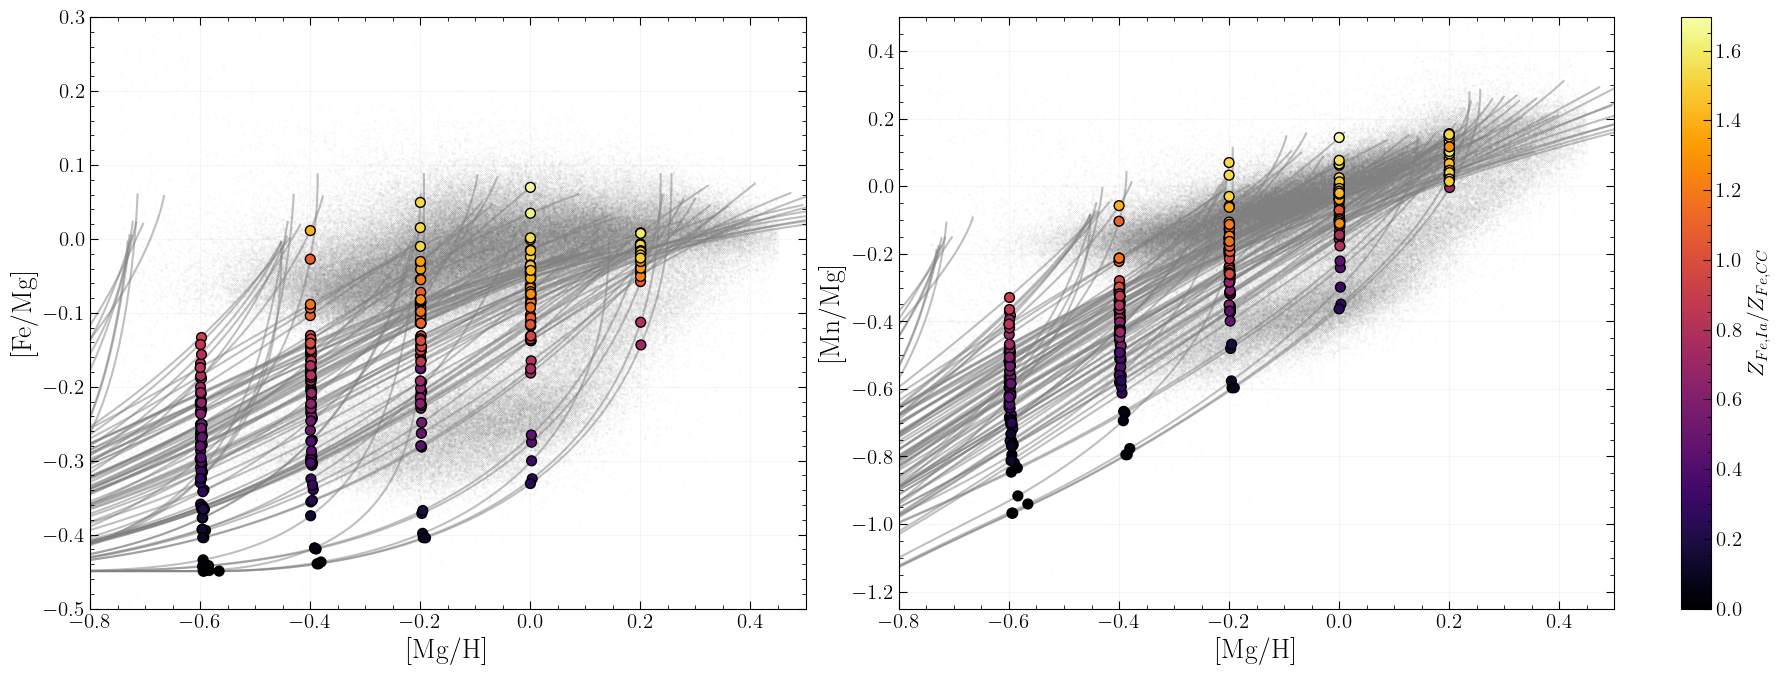

In [76]:
# Assuming endpoints is already calculated via find_endpoints()
ratio_data = compute_ratios(random_gals_list, endpoints, element='Fe')

plot_2_panel_evolution(
    data=data, 
    gals_list=random_gals_list, 
    endpoints=endpoints,
    color_by='ratio', 
    ratio_data=ratio_data, 
    ratio_label=r'$Z_{Fe, Ia} / Z_{Fe, CC}$'
)